# Spectrum robustness of gauge-induced excess error

This self-contained synthetic experiment varies only the singular-spectrum decay while holding matrix dimensions, singular bases, gauge families, and trial seeds fixed. The two heatmaps report median RBLA excess error over the dense rank-constrained optimum. Compact SP+ is evaluated and numerically checked but is not assigned a redundant near-zero heatmap.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
from matplotlib.patches import Rectangle

D_OUT, D_IN, R = 128, 96, 16
RANKS = tuple(range(1, R + 1))
ALPHAS = (0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0)
GAUGE_TYPES = ("permutation", "orthogonal")
TRIALS_PER_TYPE = 100
SEED = 42
TARGET_SEED = 20260903
TOL = 1e-10
EPS = np.finfo(np.float64).eps

cwd = Path.cwd().resolve()
OUTPUT_DIR = cwd if cwd.name == "spectrum_robustness_heatmap" else cwd / "rbla+" / "figures" / "spectrum_robustness_heatmap"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
paper_font = "Times New Roman" if "Times New Roman" in available_fonts else "DejaVu Serif"
mpl.rcParams.update({
    "font.family": paper_font, "font.size": 8, "axes.labelsize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "axes.titlesize": 8,
    "axes.linewidth": 0.8, "pdf.fonttype": 42, "ps.fonttype": 42,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})
print(f"Output directory: {OUTPUT_DIR}")
print(f"Configuration: {D_OUT} x {D_IN}, R={R}, alphas={ALPHAS}, trials/type={TRIALS_PER_TYPE}")

Output directory: H:\paper-experiment-record\rbla+\figures\spectrum_robustness_heatmap
Configuration: 128 x 96, R=16, alphas=(0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0), trials/type=100


In [2]:
def orthonormal_columns(rng, rows, columns):
    q, r = np.linalg.qr(rng.standard_normal((rows, columns)), mode="reduced")
    signs = np.where(np.diag(r) < 0.0, -1.0, 1.0)
    return q * signs[None, :]


def make_factors(u, v, alpha):
    spectrum = np.exp(-alpha * np.arange(R) / (R - 1))
    spectrum = spectrum / np.linalg.norm(spectrum)
    sqrt_s = np.sqrt(spectrum)
    return u * sqrt_s[None, :], sqrt_s[:, None] * v.T, spectrum


def make_gauge(gauge_type, seed):
    rng = np.random.default_rng(seed)
    if gauge_type == "permutation":
        return np.eye(R)[:, rng.permutation(R)]
    if gauge_type == "orthogonal":
        return orthonormal_columns(rng, R, R)
    raise ValueError(gauge_type)


def compact_sp_plus(b_global, a_global):
    q_b, r_b = np.linalg.qr(b_global, mode="reduced")
    q_a, r_a = np.linalg.qr(a_global.T, mode="reduced")
    core = r_b @ r_a.T
    u_core, singular_values, vh_core = np.linalg.svd(core, full_matrices=False)
    sqrt_s = np.sqrt(np.maximum(singular_values, 0.0))
    b_plus = (q_b @ u_core) * sqrt_s[None, :]
    a_plus = sqrt_s[:, None] * (vh_core @ q_a.T)
    shapes = [q_b.shape, r_b.shape, q_a.shape, r_a.shape, core.shape,
              u_core.shape, vh_core.shape, b_plus.shape, a_plus.shape]
    dense_shape = (b_global.shape[0], a_global.shape[1])
    if any(shape == dense_shape for shape in shapes):
        raise AssertionError("Compact SP+ created a dense-shaped intermediate")
    return b_plus, a_plus, shapes


def relative_error(reference, approximation):
    return float(np.linalg.norm(reference - approximation, ord="fro") /
                 (np.linalg.norm(reference, ord="fro") + EPS))

In [3]:
basis_rng = np.random.default_rng(TARGET_SEED)
u_fixed = orthonormal_columns(basis_rng, D_OUT, R)
v_fixed = orthonormal_columns(basis_rng, D_IN, R)
records = []

for alpha in ALPHAS:
    b_global, a_global, designed_spectrum = make_factors(u_fixed, v_fixed, alpha)
    delta_w = b_global @ a_global  # Offline evaluator only.
    _, dense_singular_values, _ = np.linalg.svd(delta_w, full_matrices=False)
    dense_norm = np.linalg.norm(dense_singular_values)
    dense_errors = {
        r: float(np.linalg.norm(dense_singular_values[r:]) / (dense_norm + EPS))
        for r in RANKS
    }

    for type_index, gauge_type in enumerate(GAUGE_TYPES):
        for trial in range(TRIALS_PER_TYPE):
            gauge_seed = SEED + 10_000 * type_index + trial
            gauge = make_gauge(gauge_type, gauge_seed)
            condition_number = float(np.linalg.cond(gauge, p=2))
            b_gauge = b_global @ gauge
            a_gauge = np.linalg.solve(gauge, a_global)
            full_update_error = relative_error(delta_w, b_gauge @ a_gauge)
            b_plus, a_plus, compact_shapes = compact_sp_plus(b_gauge, a_gauge)
            compact_ok = all(shape != delta_w.shape for shape in compact_shapes)

            rbla_update = np.zeros_like(delta_w)
            sp_update = np.zeros_like(delta_w)
            for r in RANKS:
                rbla_update += np.outer(b_gauge[:, r - 1], a_gauge[r - 1, :])
                sp_update += np.outer(b_plus[:, r - 1], a_plus[r - 1, :])
                rbla_error = relative_error(delta_w, rbla_update)
                sp_error = relative_error(delta_w, sp_update)
                dense_error = dense_errors[r]
                sp_dense_gap = abs(sp_error - dense_error)
                common = {
                    "dataset": "synthetic", "model": "structured_low_rank_update",
                    "layer": "aggregate", "checkpoint": "N/A",
                    "seed": SEED, "gauge_seed": gauge_seed, "trial": trial,
                    "gauge_type": gauge_type, "condition_number": condition_number,
                    "d_out": D_OUT, "d_in": D_IN, "R": R, "r": r,
                    "normalized_rank": r / R, "alpha": alpha,
                    "spectrum": "normalized exp(-alpha*i/(R-1))",
                    "full_update_error": full_update_error,
                    "dense_optimal_error": dense_error,
                    "sp_plus_dense_error_gap": sp_dense_gap,
                    "compact_path_no_dense_intermediate": compact_ok,
                }
                records.append({**common, "method": "RBLA prefix",
                                "broadcast_error": rbla_error,
                                "excess_error": rbla_error - dense_error})
                records.append({**common, "method": "SP+ (compact QR)",
                                "broadcast_error": sp_error,
                                "excess_error": sp_error - dense_error})

results = pd.DataFrame.from_records(records)
rbla = results[results["method"] == "RBLA prefix"]
sp_plus = results[results["method"] == "SP+ (compact QR)"]
numeric_columns = ["condition_number", "full_update_error", "broadcast_error",
                   "dense_optimal_error", "sp_plus_dense_error_gap", "excess_error"]
checks = {
    "all gauges are well conditioned": bool(results["condition_number"].max() <= 1.0 + TOL),
    "all complete updates are gauge invariant": bool(results["full_update_error"].max() <= TOL),
    "SP+ matches every dense optimum": bool(results["sp_plus_dense_error_gap"].max() <= TOL),
    "compact SP+ has no dense-shaped intermediate": bool(results["compact_path_no_dense_intermediate"].all()),
    "all numeric values are finite": bool(np.isfinite(results[numeric_columns]).all().all()),
    "all full-rank excess errors are numerical zero": bool(
        results.loc[results["r"] == R, "excess_error"].abs().max() <= TOL
    ),
    "all RBLA excess errors are non-negative within tolerance": bool(rbla["excess_error"].min() >= -TOL),
}
all_checks_passed = all(checks.values())
results["numerical_checks_passed"] = all_checks_passed
csv_path = OUTPUT_DIR / "spectrum_robustness_heatmap.csv"
results.to_csv(csv_path, index=False, float_format="%.16e")
check_table = pd.DataFrame({"check": checks.keys(), "passed": checks.values()})
display(check_table)
assert all_checks_passed, check_table.loc[~check_table["passed"], "check"].tolist()
print(f"Saved {len(results):,} rows to {csv_path.name}")

,check,passed
0,all gauges are well conditioned,True
1,all complete updates are gauge invariant,True
2,SP+ matches every dense optimum,True
3,compact SP+ has no dense-shaped intermediate,True
4,all numeric values are finite,True
5,all full-rank excess errors are numerical zero,True
6,all RBLA excess errors are non-negative within...,True


Saved 44,800 rows to spectrum_robustness_heatmap.csv


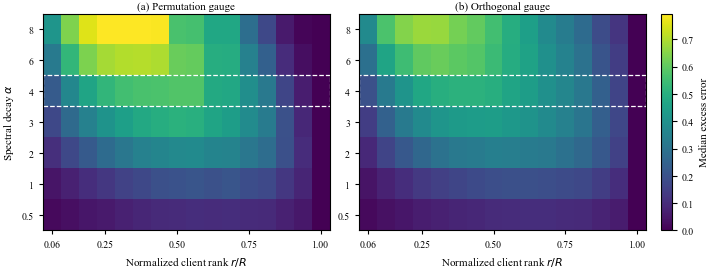

Saved vector figure to spectrum_robustness_heatmap.pdf


In [4]:
heatmap_stats = (
    rbla.groupby(["gauge_type", "alpha", "r"])["excess_error"]
    .median().rename("median_excess_error").reset_index()
)
matrices = {
    gauge_type: heatmap_stats[heatmap_stats["gauge_type"] == gauge_type]
        .pivot(index="alpha", columns="r", values="median_excess_error")
        .reindex(index=ALPHAS, columns=RANKS).to_numpy()
    for gauge_type in GAUGE_TYPES
}
color_max = max(float(matrix.max()) for matrix in matrices.values())
fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.75), constrained_layout=True)
panel_titles = {"permutation": "(a) Permutation gauge", "orthogonal": "(b) Orthogonal gauge"}
images = []
for ax, gauge_type in zip(axes, GAUGE_TYPES):
    image = ax.imshow(matrices[gauge_type], origin="lower", aspect="auto",
                      cmap="viridis", vmin=0.0, vmax=color_max, interpolation="nearest")
    images.append(image)
    tick_ranks = (1, 4, 8, 12, 16)
    ax.set_xticks([r - 1 for r in tick_ranks])
    ax.set_xticklabels([f"{r / R:.2f}" for r in tick_ranks])
    ax.set_yticks(np.arange(len(ALPHAS)))
    ax.set_yticklabels([f"{alpha:g}" for alpha in ALPHAS])
    ax.set_xlabel(r"Normalized client rank $r/R$")
    ax.set_title(panel_titles[gauge_type], pad=3)
    current_row = ALPHAS.index(4.0)
    ax.add_patch(Rectangle((-0.5, current_row - 0.5), len(RANKS), 1.0,
                           fill=False, edgecolor="white", linewidth=0.9,
                           linestyle="--"))
    ax.tick_params(direction="out", width=0.8, length=3)
axes[0].set_ylabel(r"Spectral decay $\alpha$")
colorbar = fig.colorbar(images[0], ax=axes, fraction=0.035, pad=0.025)
colorbar.set_label("Median excess error")
pdf_path = OUTPUT_DIR / "spectrum_robustness_heatmap.pdf"
fig.savefig(pdf_path)
plt.show()
print(f"Saved vector figure to {pdf_path.name}")

In [5]:
print("Spectrum robustness summary")
print(f"  alpha values: {ALPHAS}; ranks: 1..{R}; gauge trials: {len(GAUGE_TYPES) * TRIALS_PER_TYPE * len(ALPHAS):,}")
print(f"  maximum full-update invariance error: {results['full_update_error'].max():.3e}")
print(f"  maximum absolute SP+ excess error: {sp_plus['excess_error'].abs().max():.3e}")
print(f"  maximum median RBLA excess across heatmap cells: {heatmap_stats['median_excess_error'].max():.6f}")
print(f"  all numerical checks passed: {all_checks_passed}")
print("  Interpretation is limited to broadcast representation; no aggregation-stage")
print("  semantic mismatch or complete elimination of LoRA gauge is claimed.")

Spectrum robustness summary
  alpha values: (0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0); ranks: 1..16; gauge trials: 1,400
  maximum full-update invariance error: 5.133e-16
  maximum absolute SP+ excess error: 9.686e-15
  maximum median RBLA excess across heatmap cells: 0.795100
  all numerical checks passed: True
  Interpretation is limited to broadcast representation; no aggregation-stage
  semantic mismatch or complete elimination of LoRA gauge is claimed.
